In [1]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns

## Data loading:

In [3]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
dataset = MarkerDataset("CD38")
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 64


In [4]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2028
Number of batches in DataLoader: 64


In [5]:
img, label, patient_id = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([2, 140, 140])
Image max value: 0.5738561749458313
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2028


## Visualisation functions:

In [6]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)
            # Visualize first 5 images and their reconstructions
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):
                # Original
                axes[0, i].imshow(images[i, 1].cpu().numpy(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")
                # Reconstructed
                axes[1, i].imshow(recon_images[i, 1].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")
            plt.show()
            break

In [26]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for **ALL** data points in the dataloader 
    and creates two scatter plots:
      1. Latent space colored by binary labels (with legend).
      2. Latent space colored by patient IDs (with legend, no color bar).
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []
    all_patient_ids = []

    # Process **ALL** data from the dataset
    with torch.no_grad():
        for batch in dataloader:
            images, labels, patient_ids = batch  # Extract images, labels, patient_ids
            
            # Move images to device (only images go to GPU)
            images = images.to(device)

            # Get latent space representation
            mu, logvar = vae.encode(images)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std  # Shape: [batch_size, 2]

            # Ensure `labels` are tensors
            labels = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)

            # Ensure `patient_ids` are strings and map them to numeric indices
            patient_ids = np.array(patient_ids) if isinstance(patient_ids, list) else np.array(patient_ids)

            all_zs.append(z.cpu().numpy())  
            all_labels.append(labels)  
            all_patient_ids.append(patient_ids)  

    # **Concatenate** all batches into single NumPy arrays
    all_zs = np.vstack(all_zs)  # Shape: [total_samples, 2]
    all_labels = np.hstack(all_labels)  # Shape: [total_samples]
    all_patient_ids = np.hstack(all_patient_ids)  # Shape: [total_samples]

    print(f"Total data points plotted: {all_zs.shape[0]}")  # Should print ~2000

    # **Assign unique colors to each label**
    unique_labels = np.unique(all_labels)
    label_colors = sns.color_palette("Set1", len(unique_labels))  # Distinct colors for labels
    label_color_map = {label: label_colors[i] for i, label in enumerate(unique_labels)}

    # **Assign unique colors to each patient ID**
    unique_patients = np.unique(all_patient_ids)
    patient_colors = sns.color_palette("husl", len(unique_patients))  # Distinct colors for patients
    patient_color_map = {pid: patient_colors[i] for i, pid in enumerate(unique_patients)}

    # Create a figure with 2 subplots side by side
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # First plot: Color points by binary labels with a legend
    for label in unique_labels:
        mask = all_labels == label
        ax[0].scatter(all_zs[mask, 0], all_zs[mask, 1], color=label_color_map[label], label=f"Label {label}", alpha=0.7, edgecolors='k', s=10)

    ax[0].set_title('Latent Space Colored by Labels')
    ax[0].set_xlabel("z1")
    ax[0].set_ylabel("z2")
    ax[0].legend(title="Labels", loc="best")

    # Second plot: Color points by patient IDs with a legend
    for pid in unique_patients:
        mask = all_patient_ids == pid
        ax[1].scatter(all_zs[mask, 0], all_zs[mask, 1], color=patient_color_map[pid], label=f"Patient {pid}", alpha=0.7, edgecolors='k', s=10)

    ax[1].set_title('Latent Space Colored by Patient IDs')
    ax[1].set_xlabel("z1")
    ax[1].set_ylabel("z2")
    ax[1].legend(title="Patient ID", loc="best", fontsize='small', ncol=2)  # Multiple columns for better readability

    plt.tight_layout()
    plt.show()



## Autoencoders:

In [28]:
class VAE_MaxPool2(nn.Module):
    def __init__(self, img_channels=2, latent_dim=2, img_size=140):
        super(VAE_MaxPool2, self).__init__()

        # **Encoder: Uses MaxPooling for Downsampling**
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=img_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduces spatial size by half (140 → 70)
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 70 → 35
        )

        # Compute the flattened feature size after encoding
        self.flat_dim = 32 * (img_size // 4) * (img_size // 4)  # 64 x 35 x 35
        
        # Latent space representation (fully connected layers)
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)       # Mean (μ)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)   # Log variance (logσ²)

        # Linear layer to project back to feature space
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # **Decoder: Uses ConvTranspose2D to Upsample**
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1), # 35 -> 70
            nn.ReLU(),  # Use Sigmoid if images are normalized to [0,1],
            
            nn.ConvTranspose2d(32, img_channels, kernel_size=3, stride=2, padding=1, output_padding=1),  # 70 -> 140
            nn.Sigmoid()  # Sigmoid to normalize reconstructed images to [0, 1] 
        )

    def encode(self, x):
        h = self.encoder(x)             # Shape: (batch, 32, 70, 70)
        h_flat = h.view(-1, self.flat_dim)   # Flatten
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # Reparameterization trick

    def decode(self, z):
        h_flat = self.fc_decode(z)          # Map back to (batch, 32 * 70 * 70)
        h = h_flat.view(-1, 64, 35, 35)     # Reshape to feature map
        x_recon = self.decoder(h)      # Upsample to (batch, img_channels, 140, 140)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE_MaxPool2(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-4)

#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [22]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    #reconstruction_loss = F.mse_loss(recon_x, x, reduction='mean')
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence (latent space regularization)
    #logvar = torch.clamp(logvar, min=-10, max=10)  # Prevents extreme values
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return reconstruction_loss, kl_divergence

In [30]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 20
kl_weight = 0.001
#kl_weight = 1e-5  # Start extremely small
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    #kl_weight = min(0.01, kl_weight + 1e-5)  # Increase more slowly
    
    #epoch_reconstructed_images = []
    
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(data_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")

            images, _, _ = batch
            images = images.to(device)

            optimizer.zero_grad()  # Zero gradients
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            scaled_loss = recon_loss + kl_weight * kl_loss
            
            scaled_loss.backward()  # Backward pass
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=0.5)  # Gradient clipping
            
            optimizer.step()  # Optimizer step
            
            # Accumulate losses for the epoch
            epoch_total_loss += scaled_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=scaled_loss.item()
            )
            

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(data_loader)
    avg_recon_loss = epoch_recon_loss / len(data_loader)
    avg_kl_loss = epoch_kl_loss / len(data_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(data_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


Epoch 1: 100%|██████████| 64/64 [01:47<00:00,  1.68s/batch, kl_loss=1.14e+3, recon_loss=6.36e+4, total_loss=6.36e+4]


Epoch 1: Loss = 102.7251


Epoch 2: 100%|██████████| 64/64 [01:37<00:00,  1.53s/batch, kl_loss=9.82e+3, recon_loss=2.66e+4, total_loss=2.66e+4]


Epoch 2: Loss = 59.4215


Epoch 3: 100%|██████████| 64/64 [01:34<00:00,  1.48s/batch, kl_loss=1.75e+4, recon_loss=9.74e+3, total_loss=9.81e+3]


...

Epoch 13: Loss = 7.7752


Epoch 14: 100%|██████████| 64/64 [01:06<00:00,  1.04s/batch, kl_loss=3.3e+3, recon_loss=5.22e+3, total_loss=5.27e+3] 


Epoch 14: Loss = 7.6050


Epoch 15:  73%|███████▎  | 47/64 [01:46<00:38,  2.27s/batch, kl_loss=8.06e+3, recon_loss=1.44e+4, total_loss=1.45e+4]


KeyboardInterrupt: 

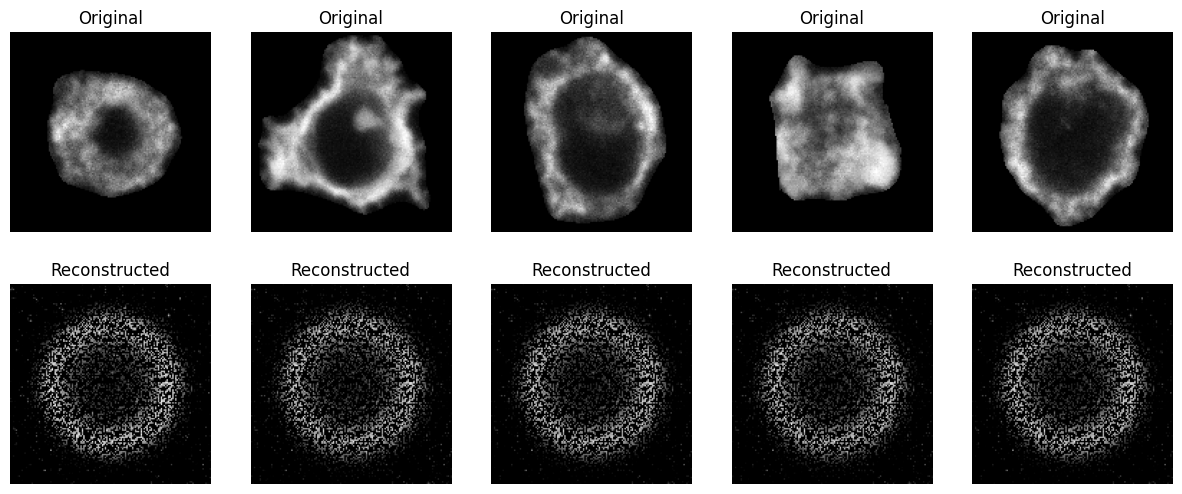

In [24]:
visualize_reconstructions(vae, data_loader, device)

Total data points plotted: 2028


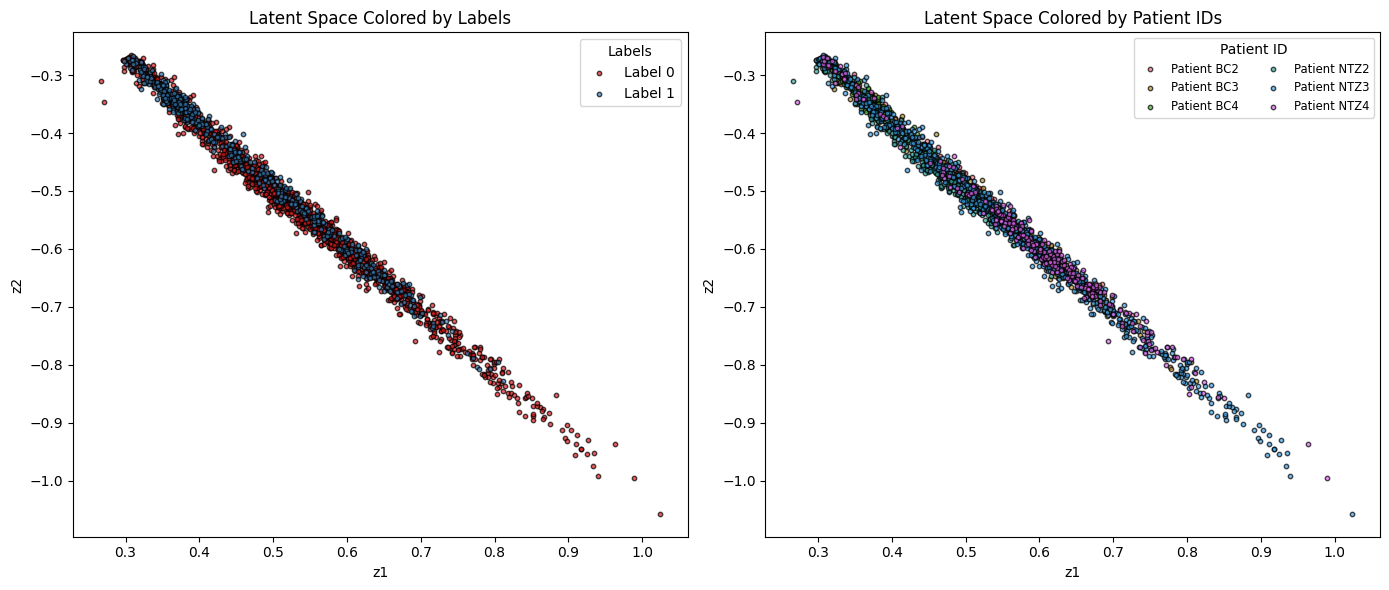

In [27]:
plot_full_latent_space(vae, data_loader, device=device)